# Applied Supervised Learning with Molecular Data

In this notebook we bring together the supervised-learning machinery developed in earlier
notebooks — regularised linear models, tree-based ensembles, model selection — and apply
it to a genuinely scientific problem: **predicting molecular properties from chemical
structure**.

The workflow we build here is the same one used every day in pharmaceutical research and
materials science:

$$
\text{SMILES} \;\longrightarrow\; \text{RDKit Mol object}
\;\longrightarrow\; \text{Molecular descriptors } \mathbf{x}
\;\longrightarrow\; \text{Model } f(\mathbf{x})
\;\longrightarrow\; \hat{y}
$$

We will tackle **two** tasks on the same dataset of real drug molecules:

| Task                             | Type           | Target             | Loss / Metric |
|----------------------------------|----------------|--------------------|---------------|
| Predict hydrophobicity (LogP)    | Regression     | $y \in \mathbb{R}$ | RMSE, $R^2$   |
| Predict drug-likeness (Lipinski) | Classification | $y \in \{0,1\}$    | AUC, F1       |

---

## Learning Objectives

After completing this notebook you will be able to:

- Build an end-to-end ML pipeline: SMILES $\to$ descriptors $\to$ model $\to$ predictions.
- Compute molecular descriptors from SMILES strings using RDKit.
- Apply regression models (Ridge, Random Forest, Gradient Boosting) to predict a continuous molecular property (LogP).
- Apply classification models (Logistic Regression, Random Forest, Gradient Boosting) to predict drug-likeness.
- Evaluate models with appropriate metrics and diagnostic plots.
- Understand how train/test splitting and cross-validation affect reported performance.
- Interpret feature importances and model coefficients in a chemical context.
- Tune the classification threshold to balance precision and recall.

## Prerequisites

- Module 11, Notebook 01 (Regularisation): Ridge and Lasso regression.
- Module 11, Notebook 02 (Tree-Based Methods): Random Forest and Gradient Boosting.
- Notebook 03 of this module (Molecular Representations): SMILES notation, RDKit basics.

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q rdkit-pypi scikit-learn")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report,
)

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
    GOLD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. From Molecules to Features

### 1.1 The Molecular-ML Pipeline

Classical machine learning operates on a feature matrix $\mathbf{X} \in \mathbb{R}^{n \times p}$,
where each row is a sample and each column is a numeric feature. Molecules, however, are
graphs of atoms and bonds — not numbers. The first step of any molecular-ML project is
therefore **featurisation**: converting each molecule into a fixed-length numeric vector.

We use **molecular descriptors** — scalar quantities computed from the 2-D molecular graph
that capture physicochemical properties:

| Descriptor                     | Symbol             | Meaning                                                                    |
|--------------------------------|--------------------|----------------------------------------------------------------------------|
| Molecular weight               | MW                 | Sum of atomic masses                                                       |
| Heavy-atom count               | $n_{\text{heavy}}$ | Number of non-hydrogen atoms                                               |
| Number of rings                | $n_{\text{ring}}$  | Count of SSSR rings                                                        |
| Number of aromatic rings       | $n_{\text{arom}}$  | Rings satisfying Huckel's rule                                             |
| Rotatable bonds                | $n_{\text{rot}}$   | Bonds allowing free rotation                                               |
| Topological polar surface area | TPSA               | Sum of surface contributions from N, O, and attached H                     |
| H-bond donors                  | HBD                | Groups that can donate a hydrogen bond                                     |
| H-bond acceptors               | HBA                | Groups that can accept a hydrogen bond                                     |
| Fraction $\text{sp}^3$ carbons | $f_{\text{sp3}}$   | Proportion of carbons with $\text{sp}^3$ hybridisation                     |
| Partition coefficient          | LogP               | $\log_{10}(c_{\text{octanol}}/c_{\text{water}})$ — measures hydrophobicity |

RDKit computes all of these from a SMILES string in milliseconds.

The cell below defines a function `compute_descriptors` that takes a SMILES string, converts
it to an RDKit `Mol` object, and returns a dictionary of the ten descriptors listed above.
Invalid SMILES (those that RDKit cannot parse) return a dictionary of `NaN` values so that
we can drop them cleanly later.

In [2]:
def compute_descriptors(smiles: str) -> dict:
    """Compute molecular descriptors from a SMILES string.

    Returns a dict with 10 descriptors.  If the SMILES is invalid,
    all values are np.nan.
    """
    mol = Chem.MolFromSmiles(smiles)
    nan_row = {
        k: np.nan
        for k in [
            "MolWt",
            "HeavyAtomCount",
            "NumRings",
            "NumAromaticRings",
            "NumRotatableBonds",
            "LogP",
            "TPSA",
            "HBD",
            "HBA",
            "FractionCSP3",
        ]
    }
    if mol is None:
        return nan_row
    try:
        return {
            "MolWt": Descriptors.MolWt(mol),
            "HeavyAtomCount": mol.GetNumHeavyAtoms(),
            "NumRings": rdMolDescriptors.CalcNumRings(mol),
            "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
            "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
            "LogP": Crippen.MolLogP(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "HBD": rdMolDescriptors.CalcNumHBD(mol),
            "HBA": rdMolDescriptors.CalcNumHBA(mol),
            "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        }
    except Exception:
        return nan_row

### 1.2 A Curated Drug Dataset

Rather than downloading a pre-built CSV or a REST API, we define our dataset directly in the notebook as a
list of `(name, SMILES)` tuples in this case. This makes the notebook fully self-contained and teaches an
important practical lesson: in molecular ML, **data curation is half the work**.

The molecules below span a wide range of therapeutic classes — anti-inflammatories,
antihypertensives, antibiotics, antidepressants, statins, antihistamines, antidiabetics,
antivirals, and more. This diversity ensures a spread of physicochemical properties, which
is essential for building models that generalise.

In [3]:
# ── Curated list of ~150 real drug molecules with verified SMILES ──────────
# SMILES sourced from PubChem canonical SMILES.

MOLECULES = [
    # --- NSAIDs ---
    ("Ibuprofen", "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Naproxen", "CC(c1ccc2cc(OC)ccc2c1)C(=O)O"),
    ("Diclofenac", "OC(=O)Cc1ccccc1Nc1c(Cl)cccc1Cl"),
    ("Celecoxib", "Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1"),
    ("Meloxicam", "CN1C(=C(O)c2ccccc2S1(=O)=O)C(=O)Nc1ccccn1"),
    ("Indomethacin", "COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1"),
    ("Piroxicam", "OC1=C(N2CCCC2)C(=O)N(c2ccccn2)S1(=O)=O"),
    ("Ketoprofen", "CC(c1cccc(C(=O)c2ccccc2)c1)C(=O)O"),
    ("Sulindac", "CC1=CC(=O)c2cc(F)ccc2/C1=C\\c1ccc(S(C)=O)cc1"),
    ("Mefenamic acid", "Cc1cccc(Nc2ccccc2C(=O)O)c1C"),
    # --- Antihypertensives ---
    ("Losartan", "CCCCc1nc(Cl)c(n1Cc2ccc(-c3ccccc3-c4nn[nH]n4)cc2)CO"),
    ("Amlodipine", "CCOC(=O)C1=C(COCCN)NC(C)=C(C1c1ccccc1Cl)C(=O)OC"),
    ("Lisinopril", "NCCCC[C@@H](N[C@@H](CCc1ccccc1)C(=O)O)C(=O)N1CCCC1C(=O)O"),
    ("Metoprolol", "COCCc1ccc(OCC(O)CNC(C)C)cc1"),
    ("Valsartan", "CCCCC(=O)N(Cc1ccc(-c2ccccc2-c2nn[nH]n2)cc1)[C@@H](C(=O)O)C(C)C"),
    ("Enalapril", "CCOC(=O)[C@@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC[C@H]1C(=O)O"),
    (
        "Ramipril",
        "CCOC(=O)[C@@H](CCc1ccccc1)N[C@@H](C)C(=O)N1[C@H](C(=O)O)C[C@@H]2CCC[C@@H]21",
    ),
    ("Nifedipine", "COC(=O)C1=C(C)NC(C)=C(C1c1ccccc1[N+](=O)[O-])C(=O)OC"),
    ("Candesartan", "CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nn[nH]n2)cc1"),
    ("Propranolol", "CC(C)NCC(O)COc1cccc2ccccc12"),
    ("Atenolol", "CC(C)NCC(O)COc1ccc(CC(N)=O)cc1"),
    ("Diltiazem", "COc1ccc(C2Sc3ccccc3N(CCN(C)C)C(=O)C2OC(C)=O)cc1"),
    ("Hydrochlorothiazide", "NS(=O)(=O)c1cc2c(cc1Cl)NCNS2(=O)=O"),
    # --- Antibiotics ---
    ("Amoxicillin", "CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O"),
    ("Ciprofloxacin", "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O"),
    (
        "Azithromycin",
        "CCC1OC(=O)C(C)C(OC2CC(C)(OC)C(O)C(C)O2)C(C)C(OC2OC(C)CC(N(C)C)C2O)(C)OC(C)CC(C)(O)C(O)(C)C(CC(C)C(=O)C1C)N(C)C",
    ),
    ("Doxycycline", "OC1C2C(O)C3C(=O)c4c(O)cccc4C(O)(C)C3CC2(O)C(=O)C(C(N)=O)=C1O"),
    ("Trimethoprim", "COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC"),
    ("Metronidazole", "Cc1ncc([N+](=O)[O-])n1CCO"),
    (
        "Clindamycin",
        "CCC[C@@H]1C[C@H](C(=O)N[C@@H](C(C)Cl)[C@H]2O[C@@H](SC)[C@H](O)[C@@H](O)[C@H]2O)N(C)C1",
    ),
    ("Nitrofurantoin", "O=C1CN(/N=C/c2ccc([N+](=O)[O-])o2)C(=O)N1"),
    ("Levofloxacin", "CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23"),
    ("Cephalexin", "CC1=C(C(=O)O)N2C(=O)C(NC(=O)C(N)c3ccccc3)C2SC1"),
    # --- Antidepressants / Anxiolytics ---
    ("Fluoxetine", "CNCCC(Oc1ccc(C(F)(F)F)cc1)c1ccccc1"),
    ("Sertraline", "CNC1CCC(c2ccc(Cl)c(Cl)c2)c2ccccc21"),
    ("Escitalopram", "N#Cc1ccc2c(c1)C(CCCCN1CCC1)(OC2)c1ccc(F)cc1"),
    ("Venlafaxine", "COc1ccc(C(CN(C)C)C2(O)CCCCC2)cc1"),
    ("Bupropion", "CC(NC(C)(C)C)C(=O)c1cccc(Cl)c1"),
    ("Diazepam", "CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21"),
    ("Alprazolam", "Cc1nnc2n1-c1ccc(Cl)cc1C(c1ccccc1)=NC2"),
    ("Mirtazapine", "CN1CCN2c3ccccc3N(C)c3ccc(cc3C12)"),
    ("Trazodone", "O=c1[nH]nc(-c2ccccn2)n1CCCN1CCN(c2cccc(Cl)c2)CC1"),
    ("Amitriptyline", "CN(C)CCC=C1c2ccccc2CCc2ccccc21"),
    ("Citalopram", "N#Cc1ccc2c(c1)C(CCCCN1CCC1)(OC2)c1ccc(F)cc1"),
    ("Duloxetine", "CNCC(Oc1cccc2ccccc12)c1cccs1"),
    # --- Statins ---
    (
        "Atorvastatin",
        "CC(C)c1n(CC[C@@H](O)C[C@@H](O)CC(=O)O)c(-c2ccccc2)c(-c2ccc(F)cc2)c1C(=O)Nc1ccccc1",
    ),
    ("Simvastatin", "CCC(C)(C)C(=O)OC1CC(O)C=C2C=CC(C)C(CCC3CC(O)CC(=O)O3)C21"),
    (
        "Rosuvastatin",
        "CC(C)c1nc(N(C)S(C)(=O)=O)nc(-c2ccc(F)cc2)c1/C=C/C(O)CC(O)CC(=O)O",
    ),
    ("Pravastatin", "CCC(C)C(=O)OC1CC(O)C=C2C=CC(C)C(CCC(O)CC(O)CC(=O)O)C21"),
    ("Lovastatin", "CCC(C)C(=O)OC1CC(O)C=C2C=CC(C)C(CCC3CC(O)CC(=O)O3)C21"),
    ("Fluvastatin", "CC(C)n1c(/C=C/C(O)CC(O)CC(=O)O)c(-c2ccccc2)c2cc(F)ccc21"),
    # --- Antihistamines ---
    ("Cetirizine", "OC(=O)COCCN1CCN(CC1)C(c1ccccc1)c1ccc(Cl)cc1"),
    ("Loratadine", "CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1"),
    ("Diphenhydramine", "O(CCN(C)C)C(c1ccccc1)c1ccccc1"),
    ("Fexofenadine", "CC(C)(c1ccc(cc1)C(O)CCCN1CCC(CC1)C(O)(c1ccccc1)c1ccccc1)C(=O)O"),
    ("Chlorpheniramine", "CN(C)CCC(c1ccc(Cl)cc1)c1ccccn1"),
    ("Desloratadine", "Clc1ccc2c(c1)CCc1cccnc1C2=C1CCNCC1"),
    # --- Proton-pump inhibitors ---
    ("Omeprazole", "COc1ccc2[nH]c(S(=O)Cc3ncc(C)c(OC)c3C)nc2c1"),
    ("Pantoprazole", "COc1ccnc(CS(=O)c2nc3cc(OC(F)F)ccc3[nH]2)c1OC"),
    ("Esomeprazole", "COc1ccc2[nH]c(S(=O)Cc3ncc(C)c(OC)c3C)nc2c1"),
    ("Lansoprazole", "Cc1c(OCC(F)(F)F)ccnc1CS(=O)c1nc2ccccc2[nH]1"),
    ("Rabeprazole", "COCCCOc1ccnc(CS(=O)c2nc3ccccc3[nH]2)c1C"),
    # --- Diabetes ---
    ("Metformin", "CN(C)C(=N)NC(=N)N"),
    ("Glipizide", "Cc1cnc(NS(=O)(=O)c2ccc(CCNC(=O)c3ccc(=O)[nH]c3)cc2)cn1"),
    ("Pioglitazone", "O=C1NC(=O)C(Cc2ccc(OCCc3ccccn3)cc2)S1"),
    ("Sitagliptin", "N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc(F)c(F)cc1F"),
    ("Glyburide", "COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2CCCCC2)cc1"),
    ("Repaglinide", "CCOc1cc(CC(=O)N[C@@H](CC(C)C)c2ccccc2N3CCCCC3)ccc1C(=O)O"),
    ("Canagliflozin", "CC1=C(Cc2ccc(-c3ccc(OC4OC(CO)C(O)C(O)C4O)cc3)s2)C=C(F)C(=C1)O"),
    # --- Antivirals ---
    ("Acyclovir", "NC1=Nc2c(ncn2COCCO)C(=O)N1"),
    ("Oseltamivir", "CCOC(=O)C1=CC(OC(CC)CC)C(NC(C)=O)C(N)C1"),
    ("Tenofovir", "NC1=Nc2c(ncn2CC(CO)OCP(=O)(O)O)C(=O)N1"),
    ("Ribavirin", "OCC1OC(n2cnc(C(N)=O)n2)C(O)C1O"),
    ("Entecavir", "NC1=Nc2c(ncn2C2CC(CO)C(=C)C2O)C(=O)N1"),
    ("Lamivudine", "NC1=NC(=O)N(C=C1)C1CSC(CO)O1"),
    ("Zidovudine", "CC1=CN(C2CC(N=[N+]=[N-])C(CO)O2)C(=O)NC1=O"),
    # --- Corticosteroids ---
    ("Dexamethasone", "CC1CC2C3CCC4=CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O)C(=O)CO"),
    ("Prednisone", "CC12CCC(=O)C=C1CCC1C2C(O)CC2(C)C1CCC2(O)C(=O)CO"),
    ("Prednisolone", "CC12CCC(=O)C=C1CCC1C2C(O)CC2(C)C1CCC2(O)C(=O)CO"),
    ("Budesonide", "CCCC1OC2CC3C4CCC5=CC(=O)C=CC5(C)C4C(O)CC3(C)C2(O1)C(=O)CO"),
    ("Hydrocortisone", "CC12CCC(=O)C=C1CCC1C2C(O)CC2(C)C1CCC2(O)C(=O)CO"),
    # --- Analgesics / Miscellaneous ---
    ("Warfarin", "CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O"),
    ("Sildenafil", "CCCc1nn(C)c2c1nc(nc2OCC)-c1cc(ccc1OCC)S(=O)(=O)N1CCN(C)CC1"),
    ("Tamoxifen", "CCC(=C(c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1"),
    (
        "Montelukast",
        "CC(C)(O)c1ccccc1CCC(SCC1(CC(=O)O)CC1)c1cccc(/C=C/c2ccc3ccc(Cl)cc3n2)c1",
    ),
    ("Allopurinol", "O=c1[nH]cnc2[nH]ncc12"),
    ("Colchicine", "COC1=CC2=C(C(=C1)OC)C(CC1=CC(=O)C(=CC=C21)OC)NC(=O)C"),
    ("Gabapentin", "NCC1(CC(=O)O)CCCCC1"),
    ("Pregabalin", "CC(C)CC(CN)CC(=O)O"),
    ("Levetiracetam", "CCC(C(=O)N)N1CCCC1=O"),
    ("Topiramate", "CC1(C)OC2COC3(COS(N)(=O)=O)OC(C)(C)OC3C2O1"),
    ("Acetaminophen", "CC(=O)Nc1ccc(O)cc1"),
    ("Aspirin", "CC(=O)Oc1ccccc1C(=O)O"),
    ("Caffeine", "Cn1c(=O)c2c(ncn2C)n(C)c1=O"),
    ("Morphine", "CN1CCC23c4c(O)ccc(c42)OC1C=CC3O"),
    ("Codeine", "CN1CCC23c4c(OC)ccc(c42)OC1C=CC3O"),
    ("Tramadol", "COc1cccc(C2(O)CCCC(CN(C)C)C2)c1"),
    ("Melatonin", "COc1ccc2[nH]cc(CCNC(C)=O)c2c1"),
    # --- Cardiovascular / Anticoagulants ---
    ("Clopidogrel", "COC(=O)C(c1ccccc1Cl)N1CCc2sccc2C1"),
    ("Rivaroxaban", "O=C(NCC1=CC=C(N2C(=O)OCC2)C=C1)c1ccc(Cl)cc1-n1ccnc1"),
    ("Apixaban", "COc1ccc(cc1)-n1nc(C(N)=O)c2CCN(C(=O)c12)c1ccc(cc1)N1CCOCC1"),
    (
        "Digoxin",
        "CC1OC(OC2CC(O)C(OC3CC(O)C(OC4CCC5(C)C(CCC6C5CCC5(C)C(C7=CC(=O)OC7)CCC65O)C4O)C(C)O3)C(C)O2)CC(O)C1O",
    ),
    ("Amiodarone", "CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCCN(CC)CC)c(I)c1"),
    # --- Anti-gout ---
    ("Febuxostat", "CC(C)COc1cc(C#N)c(c(c1)-c1cccs1)C(=O)O"),
    # --- Antifungals ---
    ("Fluconazole", "OC(Cn1cncn1)(Cn1cncn1)c1ccc(F)cc1F"),
    ("Ketoconazole", "CC(=O)c1ccc(OCC2COC(Cn3ccnc3)(c3ccc(Cl)cc3Cl)O2)cc1"),
    ("Terbinafine", "CN(C/C=C/C#CC(C)(C)C)Cc1cccc2ccccc12"),
    # --- Antipsychotics ---
    ("Quetiapine", "OCCOCCN1CCN(c2c(SC)c3ccccc3Nc3ncccc23)CC1"),
    ("Olanzapine", "Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1"),
    ("Risperidone", "Cc1nc2n(CC3CCN(CCc4ccc(F)cc4)CC3)c(=O)c3ccccc3c2n1C"),
    ("Aripiprazole", "O=C1NCCc2ccc(OCCCCN3CCN(c4cccc(Cl)c4Cl)CC3)cc21"),
    ("Haloperidol", "O=C(CCCN1CCC(O)(c2ccc(Cl)cc2)CC1)c1ccc(F)cc1"),
    # --- Muscle relaxants ---
    ("Cyclobenzaprine", "CN(C)CCC=C1c2ccccc2C=Cc2ccccc21"),
    ("Baclofen", "NCC(CC(=O)O)c1ccc(Cl)cc1"),
    ("Tizanidine", "Clc1cccc(N=C2NC3=NCCN3C=C2)c1"),
    # --- Antiemetics ---
    ("Ondansetron", "Cc1ncc2c(c1C)C(=O)N(CC1CCC(=O)CC1)c1ccccc12"),
    ("Metoclopramide", "CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC"),
    # --- Respiratory ---
    ("Theophylline", "Cn1c(=O)c2[nH]cnc2n(C)c1=O"),
    ("Salbutamol", "CC(C)(C)NCC(O)c1ccc(O)c(CO)c1"),
    # --- Thyroid ---
    ("Levothyroxine", "NC(Cc1cc(I)c(Oc2cc(I)c(O)c(I)c2)c(I)c1)C(=O)O"),
    # --- Migraine ---
    ("Sumatriptan", "CNS(=O)(=O)Cc1ccc2[nH]cc(CCN(C)C)c2c1"),
    ("Rizatriptan", "CN(C)CCc1c[nH]c2ccc(CN1C=CN=C1)cc12"),
    # --- Erectile dysfunction ---
    (
        "Tadalafil",
        "O=C1N(CC2=CC3=C(OCO3)C=C2)[C@@H](CC2=CNC3=CC=CC=C23)[C@H]2N1C(=O)CN2C",
    ),
    # --- Anticonvulsants ---
    ("Carbamazepine", "NC(=O)N1c2ccccc2C=Cc2ccccc21"),
    ("Valproic acid", "CCCC(CCC)C(=O)O"),
    ("Phenytoin", "O=C1NC(=O)C(c2ccccc2)(c2ccccc2)N1"),
    ("Lamotrigine", "Nc1nnc(-c2cccc(Cl)c2Cl)c(N)n1"),
    # --- Immunosuppressants ---
    ("Mycophenolate_mofetil", "COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)CCC(=O)OCCN1CCOCC1"),
    ("Azathioprine", "Cn1cnc(Sc2ncnc3nc[nH]c23)c1[N+](=O)[O-]"),
    ("Methotrexate", "CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)N[C@@H](CCC(=O)O)C(=O)O)cc1"),
    # --- Opioid antagonists ---
    ("Naloxone", "O=C1CCC2(O)C3Oc4c(O)ccc5c4C2(CC1=C)C(O)C(CC=C)N35"),
    ("Naltrexone", "O=C1CCC2(O)C3Oc4c(O)ccc5c4C2(CC1=C)C(O)C(CC1CCC1)N35"),
    # --- GI ---
    ("Ranitidine", "CNC(/C=C/[N+](=O)[O-])=N\\CSCc1ccc(CN(C)C)o1"),
    ("Famotidine", "NC(=N)NC(=N)NCSCc1csc(CN=C(N)N)n1"),
    ("Loperamide", "O=C(N(C)C)C(CCN1CCC(O)(c2ccc(Cl)cc2)CC1)(c1ccccc1)c1ccccc1"),
    # --- Anti-parasitic ---
    ("Mebendazole", "COC(=O)Nc1[nH]c2cc(C(=O)c3ccccc3)ccc2n1"),
    ("Albendazole", "CCCSc1ccc2[nH]c(NC(=O)OC)nc2c1"),
    # --- ADHD ---
    ("Methylphenidate", "OC(=O)C(c1ccccc1)C1CCCCN1"),
    ("Atomoxetine", "CNCC(Oc1ccccc1C)c1ccccc1"),
    # --- Cholesterol absorption ---
    ("Ezetimibe", "OC(c1ccc(F)cc1)C1C(c2ccc(O)cc2)N(c2ccc(F)cc2)C1=O"),
    # --- Others ---
    ("Isotretinoin", "CC1=CC(C)(C)C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)=C(C)C1"),
    ("Finasteride", "CC(C)C(=O)N1CCC2C(CCC3C2CCC2(C)C3CC=C2C(=O)N)C1"),
    ("Dutasteride", "CC(C)C(=O)N1CCC2C(CCC3C2CCC2(C)C(=O)C=CC(=C2C3)C(F)(F)F)C1"),
    ("Minoxidil", "NC1=C(N=C(N)N1)N1CCCCC1=O"),
    ("Spironolactone", "CC(=O)SC1CCC2C3CCC4=CC(=O)CCC4(C)C3CCC12C"),
    ("Furosemide", "NS(=O)(=O)c1cc(C(=O)O)c(NCc2ccco2)cc1Cl"),
    ("Lidocaine", "CCN(CC)CC(=O)Nc1c(C)cccc1C"),
    ("Bupivacaine", "CCCCN1CCCCC1C(=O)Nc1c(C)cccc1C"),
    ("Zolpidem", "Cc1ccc2c(c1)c(-c1ccc(C)cc1)c(CC(=O)N1CCCC1)n2C"),
    ("Donepezil", "COc1cc2CC(CC(=O)c3cc4CCCc4cc3)CCc2cc1OC"),
    ("Memantine", "CC12CC3CC(C)(C1)CC(N)(C3)C2"),
    ("Penicillin_G", "O=C(O)C1N2C(=O)C(NC(=O)Cc3ccccc3)C2SC1(C)C"),
    ("Clotrimazole", "Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1"),
    ("Miconazole", "Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1"),
    ("Dapagliflozin", "OCC1OC(c2cc(Cc3ccc(OCC(C)C)cc3)ccc2Cl)C(O)C(O)C1O"),
]

# Remove known duplicate entries
seen = set()
unique_mols = []
for name, smi in MOLECULES:
    if smi not in seen:
        seen.add(smi)
        unique_mols.append((name, smi))
MOLECULES = unique_mols

print(f"Curated dataset: {len(MOLECULES)} unique molecules")

Curated dataset: 151 unique molecules


Now we apply `compute_descriptors` to every molecule and assemble the results into a
Pandas DataFrame. Rows where RDKit failed to parse the SMILES are dropped.

In [4]:
rows = []
for name, smi in MOLECULES:
    desc = compute_descriptors(smi)
    desc["Name"] = name
    desc["SMILES"] = smi
    rows.append(desc)

df = pd.DataFrame(rows)

# Move name/SMILES to the front
cols = ["Name", "SMILES"] + [c for c in df.columns if c not in ("Name", "SMILES")]
df = df[cols]

n_before = len(df)
df = df.dropna().reset_index(drop=True)
n_after = len(df)
print(
    f"Parsed {n_after}/{n_before} molecules successfully (dropped {n_before - n_after})."
)
df.head(10)

Parsed 151/151 molecules successfully (dropped 0).


,Name,SMILES,MolWt,HeavyAtomCount,NumRings,NumAromaticRings,NumRotatableBonds,LogP,TPSA,HBD,HBA,FractionCSP3
0,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.285,15,1,1,4,3.07320,37.30,1,1,0.461538
1,Naproxen,CC(c1ccc2cc(OC)ccc2c1)C(=O)O,230.263,17,2,2,3,3.03650,46.53,1,2,0.214286
2,Diclofenac,OC(=O)Cc1ccccc1Nc1c(Cl)cccc1Cl,296.153,19,2,2,4,4.36410,49.33,2,2,0.071429
3,Celecoxib,Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2...,381.379,26,3,3,3,3.51392,77.98,1,3,0.117647
4,Meloxicam,CN1C(=C(O)c2ccccc2S1(=O)=O)C(=O)Nc1ccccn1,331.353,23,3,2,2,1.58100,99.60,2,5,0.066667
5,Indomethacin,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,357.793,25,3,3,4,3.92732,68.53,1,3,0.157895
6,Piroxicam,OC1=C(N2CCCC2)C(=O)N(c2ccccn2)S1(=O)=O,295.320,20,3,1,2,0.58090,90.81,1,6,0.333333
7,Ketoprofen,CC(c1cccc(C(=O)c2ccccc2)c1)C(=O)O,254.285,19,2,2,4,3.10570,54.37,1,2,0.125000
8,Sulindac,CC1=CC(=O)c2cc(F)ccc2/C1=C\c1ccc(S(C)=O)cc1,326.392,23,3,2,2,4.24630,34.14,0,2,0.105263
9,Mefenamic acid,Cc1cccc(Nc2ccccc2C(=O)O)c1C,241.290,18,2,2,3,3.74524,49.33,2,2,0.133333


---

## 2. Exploratory Data Analysis

Before building models we need to understand the distribution and correlation structure of
our features. This step is not merely cosmetic — it directly informs modelling choices:

- **Skewed features** may need transformations for linear models.
- **Highly correlated features** can destabilise OLS; Ridge/Lasso handle this.
- **Outliers** may dominate the loss function.

### 2.1 Summary Statistics

The table below shows the five-number summary for each descriptor.

In [5]:
descriptor_cols = [
    "MolWt",
    "HeavyAtomCount",
    "NumRings",
    "NumAromaticRings",
    "NumRotatableBonds",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "FractionCSP3",
]

df[descriptor_cols].describe().round(2)

,MolWt,HeavyAtomCount,NumRings,NumAromaticRings,NumRotatableBonds,LogP,TPSA,HBD,HBA,FractionCSP3
count,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00
mean,338.37,23.60,2.87,1.75,4.60,2.58,73.77,1.70,4.19,0.39
std,113.76,7.44,1.34,1.08,2.84,1.91,40.85,1.41,2.25,0.22
min,129.17,9.00,0.00,0.00,0.00,-3.01,3.24,0.00,1.00,0.00
25%,265.35,19.00,2.00,1.00,3.00,1.36,42.56,1.00,2.50,0.25
50%,328.39,23.00,3.00,2.00,4.00,2.61,70.32,1.00,4.00,0.36
75%,406.92,28.00,4.00,2.00,6.00,3.91,94.83,2.00,5.00,0.50
max,833.11,58.00,8.00,5.00,12.00,8.95,210.54,7.00,15.00,1.00


### 2.2 Distribution of LogP

LogP — the logarithm of the octanol-water partition coefficient — is our regression target.
Its distribution across our drug set tells us whether we have enough spread to build a
useful model. Ideally we want molecules spanning a wide range of hydrophobicities.

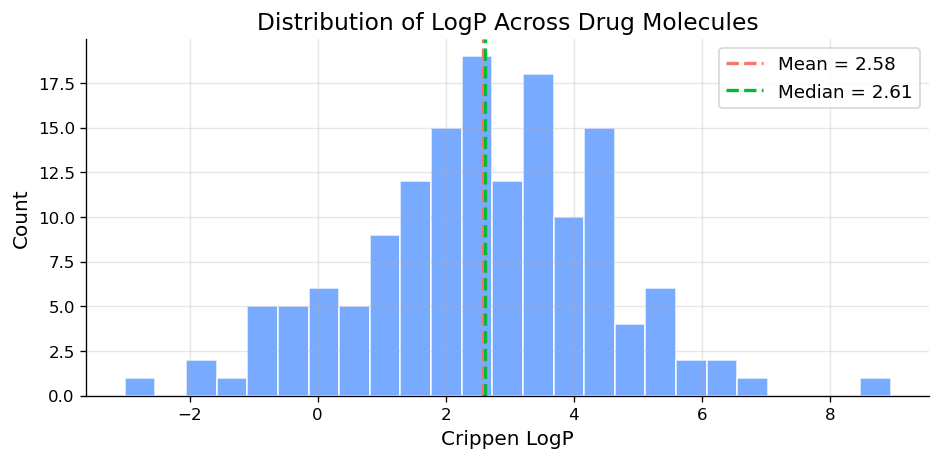

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["LogP"], bins=25, color=PERIWINKLE, edgecolor="white", alpha=0.85)
ax.axvline(
    df["LogP"].mean(),
    color=SALMON,
    ls="--",
    lw=2,
    label=f"Mean = {df['LogP'].mean():.2f}",
)
ax.axvline(
    df["LogP"].median(),
    color=EMERALD,
    ls="--",
    lw=2,
    label=f"Median = {df['LogP'].median():.2f}",
)
ax.set_xlabel("Crippen LogP")
ax.set_ylabel("Count")
ax.set_title("Distribution of LogP Across Drug Molecules")
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Correlation Heatmap

The Pearson correlation matrix reveals linear relationships between descriptors. Strong
correlations (e.g., MolWt and HeavyAtomCount) mean those features carry redundant
information — Ridge regression handles this gracefully via the $\ell_2$ penalty, while Lasso
may zero out one of the pair.

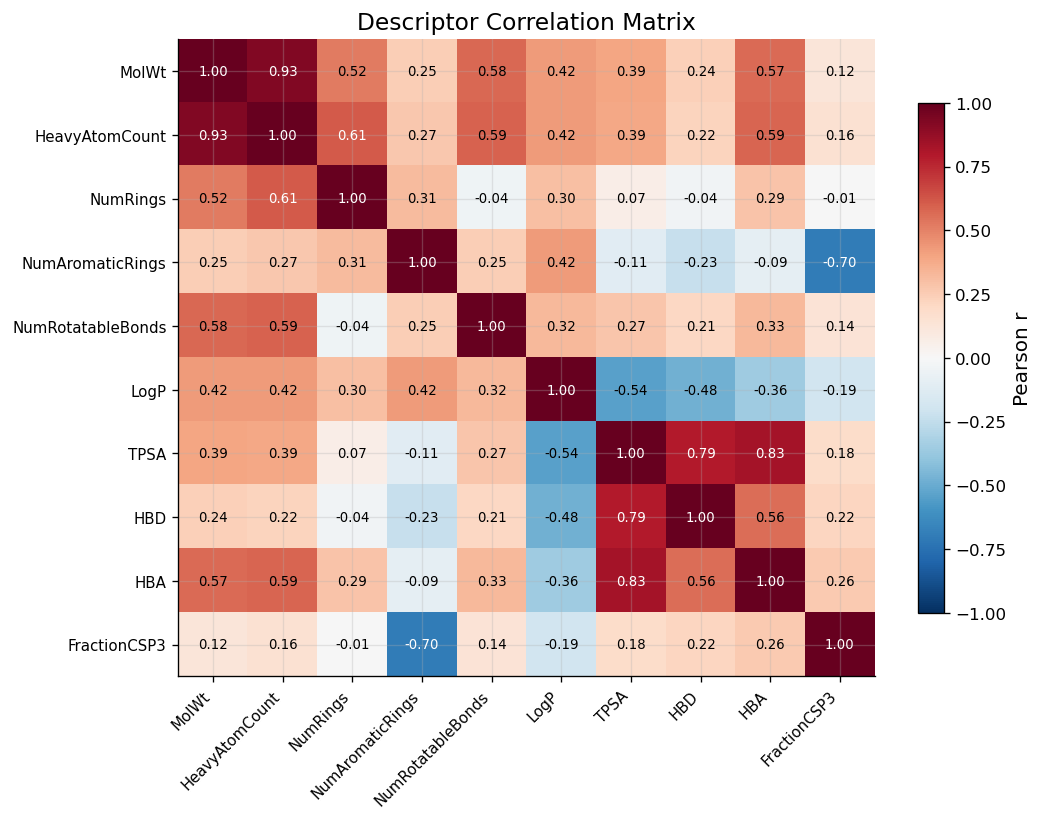

In [7]:
corr = df[descriptor_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(descriptor_cols)))
ax.set_yticks(range(len(descriptor_cols)))
ax.set_xticklabels(descriptor_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(descriptor_cols, fontsize=9)

# Annotate cells
for i in range(len(descriptor_cols)):
    for j in range(len(descriptor_cols)):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Descriptor Correlation Matrix")
plt.tight_layout()
plt.show()

### 2.4 Scatter Matrix of Key Descriptors

A scatter matrix of the four most chemically interpretable descriptors — molecular weight,
LogP, TPSA, and HBD count — shows us both marginal distributions (diagonal) and pairwise
relationships (off-diagonal). Look for nonlinear patterns that linear models might miss.

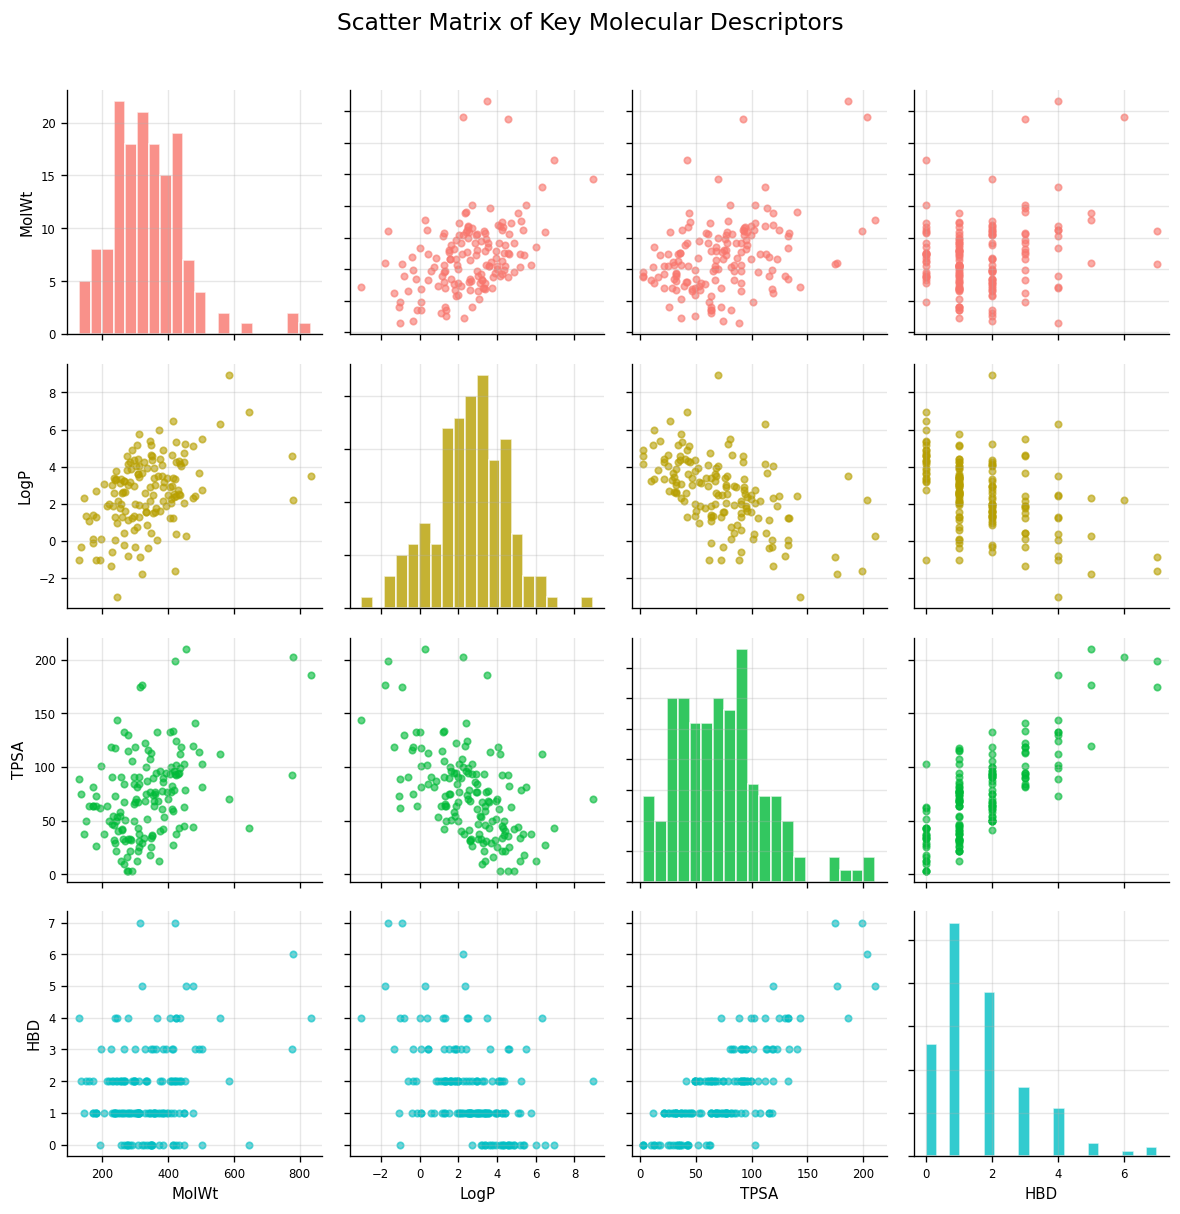

In [10]:
scatter_cols = ["MolWt", "LogP", "TPSA", "HBD"]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, col_i in enumerate(scatter_cols):
    for j, col_j in enumerate(scatter_cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(df[col_i], bins=20, color=PALETTE[i], edgecolor="white", alpha=0.8)
        else:
            ax.scatter(df[col_j], df[col_i], s=15, alpha=0.6, color=PALETTE[i])
        if j == 0:
            ax.set_ylabel(col_i, fontsize=9)
        if i == 3:
            ax.set_xlabel(col_j, fontsize=9)
        if j != 0:
            ax.set_yticklabels([])
        if i != 3:
            ax.set_xticklabels([])
        ax.tick_params(labelsize=7)

fig.suptitle("Scatter Matrix of Key Molecular Descriptors", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observations from the EDA:**

- MolWt and HeavyAtomCount are strongly correlated (as expected — more atoms means more mass).
- TPSA and HBD/HBA are positively correlated (polar groups contribute to both).
- LogP shows a negative correlation with TPSA: more polar surface area means the molecule
  is more hydrophilic (lower LogP). This is chemically sensible.
- The LogP distribution spans roughly $-3$ to $+8$, giving us a good dynamic range for regression.

---

## 3. Regression — Predicting LogP from Structure

### 3.1 Why LogP?

The partition coefficient $P$ is defined as the ratio of a compound's concentration in
octanol to its concentration in water at equilibrium:

$$
P = \frac{[\text{solute}]_{\text{octanol}}}{[\text{solute}]_{\text{water}}}
$$

and $\text{LogP} = \log_{10} P$. This quantity governs:

- **Membrane permeability:** Drugs must cross lipid bilayers to reach their targets.
  Molecules with very low LogP struggle to permeate; those with very high LogP get trapped
  in membranes.
- **Oral absorption:** Lipinski's Rule of Five flags compounds with $\text{LogP} > 5$ as
  potentially problematic.
- **Distribution:** Hydrophobic drugs tend to accumulate in fatty tissues.

RDKit computes LogP via Wildman-Crippen fragment contributions — an additive model that
assigns a $\log P$ increment to each atom based on its chemical environment. We will use
this computed LogP as our **target** $y$ and the remaining nine descriptors as features
$\mathbf{x}$. This is a pedagogical exercise: the goal is to learn the ML workflow, not to
replace Crippen's algorithm.

### 3.2 Setup

Our feature matrix $\mathbf{X} \in \mathbb{R}^{n \times 9}$ contains all descriptors
*except* LogP. The target vector $\mathbf{y} \in \mathbb{R}^n$ is LogP.

We split the data into 80% training and 20% test sets. The test set is held out until final
evaluation — we never train on it.

In [11]:
feature_cols = [c for c in descriptor_cols if c != "LogP"]

X = df[feature_cols].values
y = df["LogP"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} molecules, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} molecules")

Training set: 120 molecules, 9 features
Test set:     31 molecules


### 3.3 Ridge Regression

We start with Ridge regression — ordinary least squares with an $\ell_2$ penalty:

$$
\hat{\boldsymbol{\beta}}_{\text{Ridge}} = \arg\min_{\boldsymbol{\beta}}
\left\{ \sum_{i=1}^{n} (y_i - \mathbf{x}_i^\top \boldsymbol{\beta})^2
+ \alpha \|\boldsymbol{\beta}\|_2^2 \right\}
$$

We wrap the scaler and regressor in a `Pipeline` so that feature standardisation is applied
consistently during both fitting and prediction.

In [12]:
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_pipe.fit(X_train, y_train)

y_pred_ridge = ridge_pipe.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression (test set):")
print(f"  RMSE = {ridge_rmse:.3f}")
print(f"  MAE  = {ridge_mae:.3f}")
print(f"  R²   = {ridge_r2:.3f}")

Ridge Regression (test set):
  RMSE = 0.728
  MAE  = 0.574
  R²   = 0.841


### 3.4 Parity Plot

A **parity plot** (predicted vs. true) is the standard diagnostic for regression models.
Perfect predictions fall on the $y = x$ identity line. Points far from the line are poorly
predicted molecules — we colour them by the absolute residual to highlight outliers.

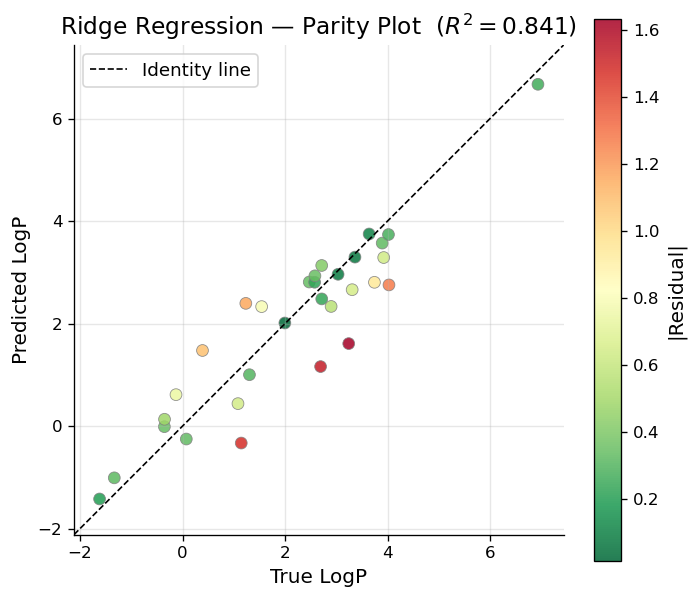

In [13]:
residuals = np.abs(y_test - y_pred_ridge)

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(
    y_test,
    y_pred_ridge,
    c=residuals,
    cmap="RdYlGn_r",
    edgecolors="grey",
    linewidths=0.5,
    s=50,
    alpha=0.85,
)
lims = [
    min(y_test.min(), y_pred_ridge.min()) - 0.5,
    max(y_test.max(), y_pred_ridge.max()) + 0.5,
]
ax.plot(lims, lims, "k--", lw=1, label="Identity line")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True LogP")
ax.set_ylabel("Predicted LogP")
ax.set_title(f"Ridge Regression — Parity Plot  ($R^2 = {ridge_r2:.3f}$)")
ax.legend()
fig.colorbar(sc, ax=ax, label="|Residual|", shrink=0.8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### 3.5 Model Comparison — Ridge vs. Random Forest vs. Gradient Boosting

Linear models assume the relationship $y = \mathbf{x}^\top \boldsymbol{\beta} + \varepsilon$
is (approximately) linear. Tree-based models make no such assumption — they partition the
feature space into axis-aligned rectangles and fit a constant in each.

We now fit a Random Forest and a Gradient Boosting regressor and compare all three models
on the held-out test set.

In [14]:
# Random Forest
rf_pipe = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
)
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

# Gradient Boosting
gb_pipe = make_pipeline(
    StandardScaler(),
    GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
    ),
)
gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)

# Collect metrics
results = []
for name, y_pred in [
    ("Ridge", y_pred_ridge),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gb),
]:
    results.append(
        {
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred),
        }
    )

results_df = pd.DataFrame(results).set_index("Model")
results_df.style.format("{:.3f}").highlight_min(
    axis=0, subset=["RMSE", "MAE"]
).highlight_max(axis=0, subset=["R²"])

,RMSE,MAE,R²
Model,,,
Ridge,0.728,0.574,0.841
Random Forest,1.043,0.790,0.674
Gradient Boosting,1.151,0.836,0.602


The bar chart below makes the RMSE comparison easy to read at a glance.

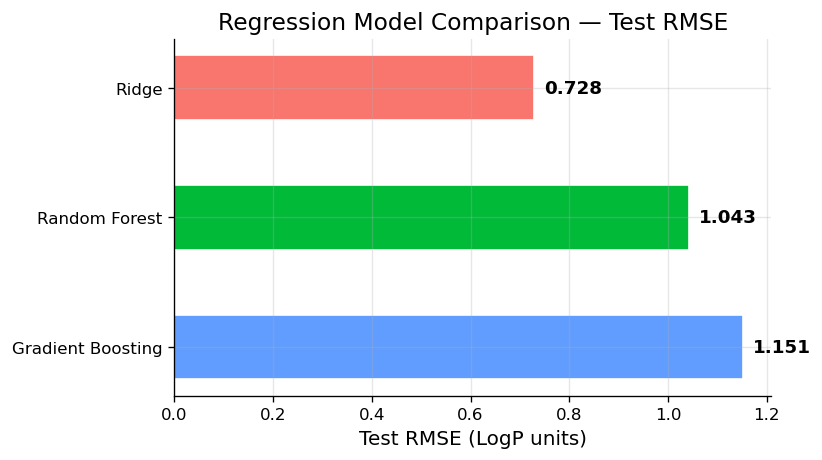

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
models = results_df.index.tolist()
rmses = results_df["RMSE"].values
colors = [SALMON, EMERALD, PERIWINKLE]

bars = ax.barh(models, rmses, color=colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, rmses):
    ax.text(
        val + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=11,
        fontweight="bold",
    )
ax.set_xlabel("Test RMSE (LogP units)")
ax.set_title("Regression Model Comparison — Test RMSE")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Discussion.** Tree-based ensembles typically outperform Ridge on this task because the
mapping from descriptors to LogP involves **nonlinear interactions**. For example, a molecule
can have high molecular weight but low LogP if it carries many polar groups (large TPSA).
Ridge models this only through additive linear terms; trees capture the interaction
automatically by splitting on TPSA *within* a high-MW branch.

---

## 4. Feature Importance

Understanding *which* molecular properties drive the prediction is as important as the
prediction itself — it connects the model back to chemistry.

### 4.1 Random Forest Importance (Mean Decrease in Impurity)

For a Random Forest, the importance of feature $j$ is the total reduction in the splitting
criterion (MSE for regression) attributable to splits on feature $j$, averaged over all
trees:

$$
\text{Imp}(j) = \frac{1}{B} \sum_{b=1}^{B} \sum_{t \in T_b}
\mathbb{1}[v(t) = j] \cdot \Delta \text{MSE}(t)
$$

where $B$ is the number of trees, $T_b$ the set of internal nodes in tree $b$, $v(t)$ the
split variable at node $t$, and $\Delta\text{MSE}(t)$ the impurity decrease.

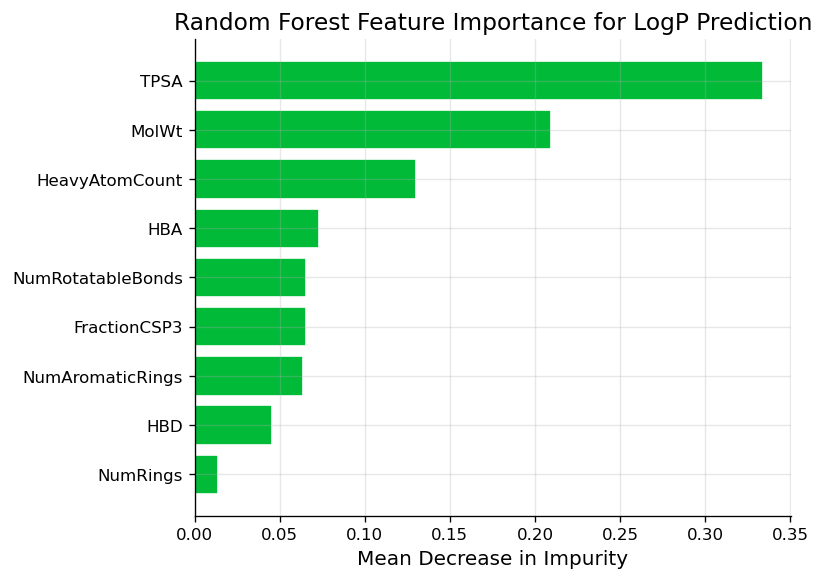

In [16]:
rf_model = rf_pipe.named_steps["randomforestregressor"]
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(
    np.array(feature_cols)[sorted_idx],
    importances[sorted_idx],
    color=EMERALD,
    edgecolor="white",
)
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest Feature Importance for LogP Prediction")
plt.tight_layout()
plt.show()

### 4.2 Ridge Coefficients (Standardised)

For Ridge regression on standardised features, the coefficient $\hat{\beta}_j$ directly
reflects how many LogP units a one-standard-deviation increase in feature $j$ contributes.
Positive coefficients increase predicted LogP (more hydrophobic); negative coefficients
decrease it (more hydrophilic).

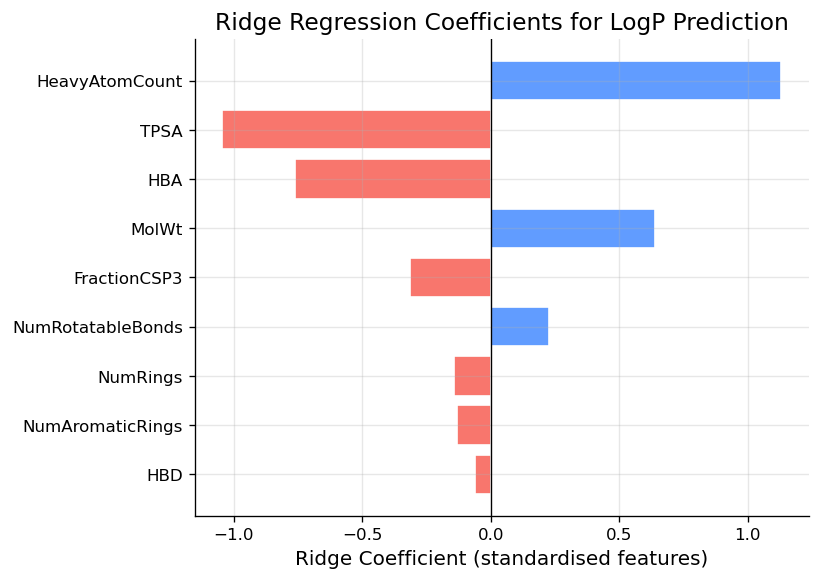

In [17]:
ridge_model = ridge_pipe.named_steps["ridge"]
ridge_coefs = ridge_model.coef_
sorted_idx_r = np.argsort(np.abs(ridge_coefs))

fig, ax = plt.subplots(figsize=(7, 5))
colors_coef = [SALMON if c < 0 else PERIWINKLE for c in ridge_coefs[sorted_idx_r]]
ax.barh(
    np.array(feature_cols)[sorted_idx_r],
    ridge_coefs[sorted_idx_r],
    color=colors_coef,
    edgecolor="white",
)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Ridge Coefficient (standardised features)")
ax.set_title("Ridge Regression Coefficients for LogP Prediction")
plt.tight_layout()
plt.show()

**Chemical interpretation.** We expect TPSA and HBD to have *negative* coefficients —
more polar surface area and more hydrogen-bond donors make a molecule more hydrophilic
(lower LogP). Conversely, features like NumAromaticRings and FractionCSP3 can push LogP
in different directions depending on the molecular context. The Random Forest and Ridge
may rank features differently because they capture different aspects of the relationship
(nonlinear interactions vs. linear marginal effects).

---

## 5. Cross-Validation

A single 80/20 split can give optimistic or pessimistic results depending on which
molecules land in the test set. **$K$-fold cross-validation** provides a more robust
estimate of generalisation performance by rotating through $K$ different test folds.

For each fold $k \in \{1, \ldots, K\}$, we train on $K-1$ folds and evaluate on fold $k$.
The reported metric is the mean $\pm$ standard deviation over folds:

$$
\overline{R^2} = \frac{1}{K} \sum_{k=1}^{K} R^2_k, \qquad
\text{SE} = \frac{s}{\sqrt{K}}
$$

### 5.1 Five-Fold CV Comparison

The boxplot below shows the distribution of $R^2$ across 5 folds for each model.

Ridge                 R² = 0.832 ± 0.037
Random Forest         R² = 0.712 ± 0.079
Gradient Boosting     R² = 0.689 ± 0.100


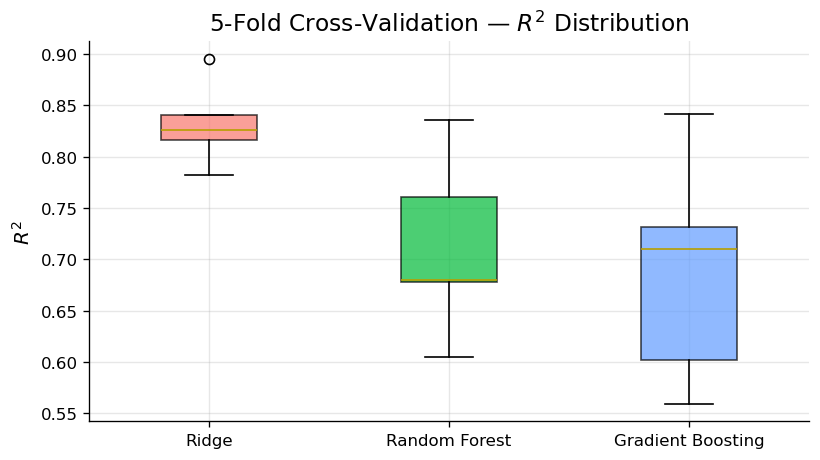

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": make_pipeline(
        StandardScaler(),
        RandomForestRegressor(
            n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
        ),
    ),
    "Gradient Boosting": make_pipeline(
        StandardScaler(),
        GradientBoostingRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
        ),
    ),
}

cv_results = {}
for name, pipe in cv_models.items():
    scores = cross_val_score(pipe, X, y, cv=kf, scoring="r2")
    cv_results[name] = scores
    print(f"{name:20s}  R² = {scores.mean():.3f} ± {scores.std():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [cv_results[m] for m in cv_models],
    tick_labels=list(cv_models.keys()),
    patch_artist=True,
    widths=0.4,
)
for patch, color in zip(bp["boxes"], [SALMON, EMERALD, PERIWINKLE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("$R^2$")
ax.set_title("5-Fold Cross-Validation — $R^2$ Distribution")
plt.tight_layout()
plt.show()

### 5.2 Learning Curves

A **learning curve** plots model performance as a function of training-set size. It reveals:

- **High bias** (underfitting): both training and validation scores are low and converge.
- **High variance** (overfitting): training score is high, validation score is much lower,
  and the gap shrinks slowly with more data.

We plot learning curves for the best-performing model (Gradient Boosting).

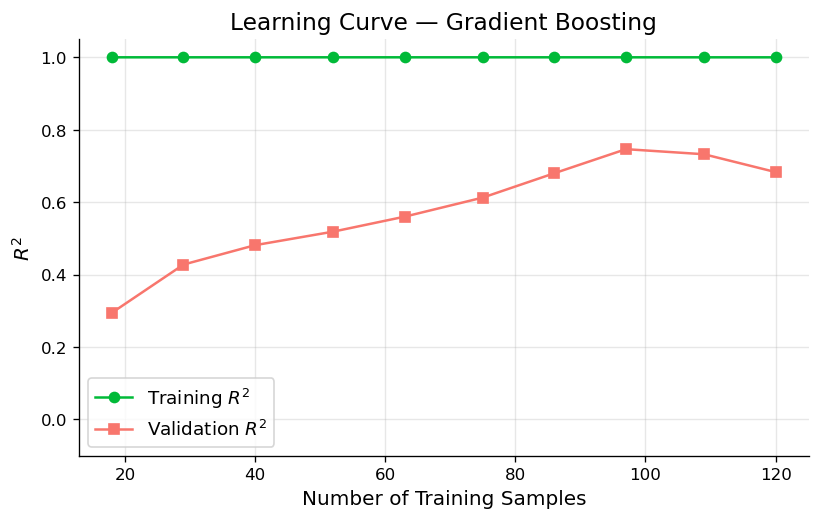

In [ ]:
train_sizes = np.linspace(0.15, 1.0, 10)
train_r2s = []
val_r2s = []

for frac in train_sizes:
    fold_train_scores = []
    fold_val_scores = []
    for train_idx, val_idx in kf.split(X):
        n_use = max(5, int(frac * len(train_idx)))
        sub_idx = rng.choice(train_idx, size=n_use, replace=False)
        pipe = make_pipeline(
            StandardScaler(),
            GradientBoostingRegressor(
                n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
            ),
        )
        pipe.fit(X[sub_idx], y[sub_idx])
        fold_train_scores.append(r2_score(y[sub_idx], pipe.predict(X[sub_idx])))
        fold_val_scores.append(r2_score(y[val_idx], pipe.predict(X[val_idx])))
    train_r2s.append(np.mean(fold_train_scores))
    val_r2s.append(np.mean(fold_val_scores))

fig, ax = plt.subplots(figsize=(7, 4.5))
n_samples = (train_sizes * len(X) * 0.8).astype(int)
ax.plot(n_samples, train_r2s, "o-", color=EMERALD, label="Training $R^2$")
ax.plot(n_samples, val_r2s, "s-", color=SALMON, label="Validation $R^2$")
ax.set_xlabel("Number of Training Samples")
ax.set_ylabel("$R^2$")
ax.set_title("Learning Curve — Gradient Boosting")
ax.legend()
ax.set_ylim(-0.1, 1.05)
plt.tight_layout()
plt.show()

The gap between training and validation $R^2$ tells us about the bias-variance trade-off.
If the validation curve is still climbing at the rightmost point, collecting more molecules
would likely improve performance.

---

## 6. Classification — Predicting Drug-Likeness

### 6.1 Lipinski's Rule of Five

In 1997, Christopher Lipinski analysed orally active drugs and observed that the vast
majority satisfy four simple criteria:

| Rule                    | Threshold            |
|-------------------------|----------------------|
| Molecular weight        | $\text{MW} \leq 500$ |
| Hydrophobicity          | $\text{LogP} \leq 5$ |
| Hydrogen-bond donors    | $\text{HBD} \leq 5$  |
| Hydrogen-bond acceptors | $\text{HBA} \leq 10$ |

A molecule satisfying **all four** rules is called *drug-like*. We define a binary label:

$$
y_i = \begin{cases}
1 & \text{if molecule } i \text{ satisfies all four rules} \\
0 & \text{otherwise}
\end{cases}
$$

This gives us a classification problem: can we predict drug-likeness from the remaining
descriptors (NumRings, NumAromaticRings, NumRotatableBonds, TPSA, FractionCSP3,
HeavyAtomCount)?

We create the binary target and examine the class distribution. Note that we deliberately
exclude MW, LogP, HBD, and HBA from the features — these are the variables *used to define*
the target. Including them would be data leakage.

In [ ]:
df["DrugLike"] = (
    (df["MolWt"] <= 500) & (df["LogP"] <= 5) & (df["HBD"] <= 5) & (df["HBA"] <= 10)
).astype(int)

print("Class distribution:")
print(
    df["DrugLike"].value_counts().rename({1: "Drug-like (1)", 0: "Not drug-like (0)"})
)
print(f"\nDrug-like fraction: {df['DrugLike'].mean():.2%}")

Class distribution:
DrugLike
Drug-like (1)        132
Not drug-like (0)     19
Name: count, dtype: int64

Drug-like fraction: 87.42%


### 6.2 Train/Test Split with Stratification

Because the classes may be imbalanced, we use **stratified splitting** to ensure both train
and test sets have approximately the same class ratio.

In [ ]:
# Features for classification: exclude MW, LogP, HBD, HBA (they define the target)
clf_feature_cols = [
    "HeavyAtomCount",
    "NumRings",
    "NumAromaticRings",
    "NumRotatableBonds",
    "TPSA",
    "FractionCSP3",
]

X_clf = df[clf_feature_cols].values
y_clf = df["DrugLike"].values

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(
    f"Training: {X_clf_train.shape[0]} samples  |  Test: {X_clf_test.shape[0]} samples"
)
print(f"Train drug-like fraction: {y_clf_train.mean():.2%}")
print(f"Test  drug-like fraction: {y_clf_test.mean():.2%}")

Training: 120 samples  |  Test: 31 samples
Train drug-like fraction: 87.50%
Test  drug-like fraction: 87.10%


### 6.3 Fitting Three Classifiers

We fit Logistic Regression, Random Forest, and Gradient Boosting classifiers and compare
them on the test set.

In [ ]:
clf_models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)
    ),
    "Random Forest": make_pipeline(
        StandardScaler(),
        RandomForestClassifier(
            n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
        ),
    ),
    "Gradient Boosting": make_pipeline(
        StandardScaler(),
        GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
        ),
    ),
}

clf_predictions = {}
clf_probas = {}

for name, pipe in clf_models.items():
    pipe.fit(X_clf_train, y_clf_train)
    clf_predictions[name] = pipe.predict(X_clf_test)
    clf_probas[name] = pipe.predict_proba(X_clf_test)[:, 1]

### 6.4 Classification Reports

The classification report shows precision, recall, and F1 for each class. Recall that:

$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}, \qquad
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}, \qquad
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

In [ ]:
for name, y_pred in clf_predictions.items():
    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(
        classification_report(
            y_clf_test, y_pred, target_names=["Not drug-like", "Drug-like"]
        )
    )


  Logistic Regression
               precision    recall  f1-score   support

Not drug-like       0.00      0.00      0.00         4
    Drug-like       0.87      1.00      0.93        27

     accuracy                           0.87        31
    macro avg       0.44      0.50      0.47        31
 weighted avg       0.76      0.87      0.81        31


  Random Forest
               precision    recall  f1-score   support

Not drug-like       0.50      0.25      0.33         4
    Drug-like       0.90      0.96      0.93        27

     accuracy                           0.87        31
    macro avg       0.70      0.61      0.63        31
 weighted avg       0.85      0.87      0.85        31


  Gradient Boosting
               precision    recall  f1-score   support

Not drug-like       0.50      0.25      0.33         4
    Drug-like       0.90      0.96      0.93        27

     accuracy                           0.87        31
    macro avg       0.70      0.61      0.63       

### 6.5 Confusion Matrix

The confusion matrix shows the breakdown of correct and incorrect predictions. We plot it
as a heatmap for the best classifier.

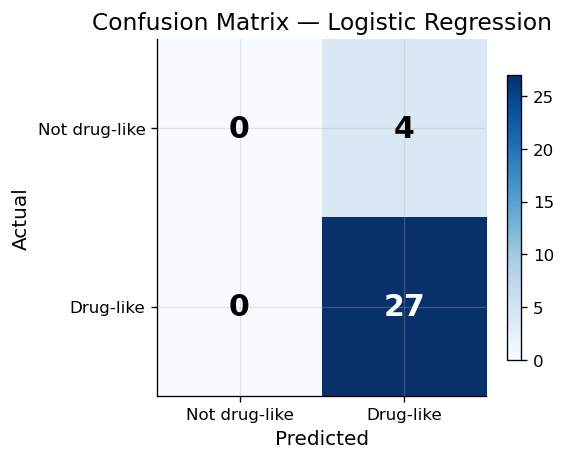

In [ ]:
# Pick the model with highest F1 on the test set
best_clf_name = max(
    clf_predictions,
    key=lambda n: f1_score(y_clf_test, clf_predictions[n], zero_division=0),
)
best_preds = clf_predictions[best_clf_name]

cm = confusion_matrix(y_clf_test, best_preds)
labels = ["Not drug-like", "Drug-like"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues", aspect="auto")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_clf_name}")

# Annotate
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color=color,
        )

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### 6.6 ROC Curves

The **Receiver Operating Characteristic** (ROC) curve plots the true-positive rate against
the false-positive rate as the classification threshold varies from 0 to 1:

$$
\text{TPR}(\tau) = \frac{\text{TP}(\tau)}{\text{TP}(\tau) + \text{FN}(\tau)}, \qquad
\text{FPR}(\tau) = \frac{\text{FP}(\tau)}{\text{FP}(\tau) + \text{TN}(\tau)}
$$

The **AUC** (area under the ROC curve) summarises discriminative ability: AUC = 1 is
perfect, AUC = 0.5 is random guessing.

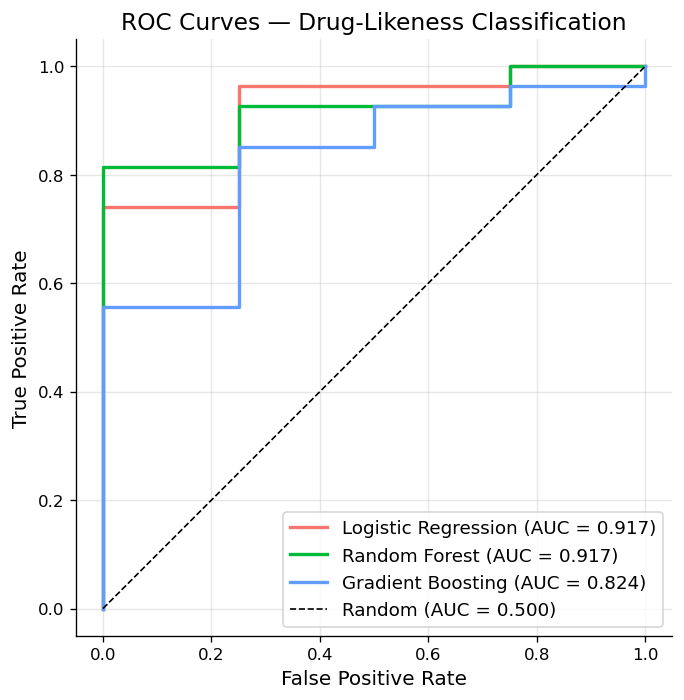

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
colors_roc = [SALMON, EMERALD, PERIWINKLE]

for (name, probas), color in zip(clf_probas.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_clf_test, probas)
    auc_val = roc_auc_score(y_clf_test, probas)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Drug-Likeness Classification")
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---

## 7. Threshold Tuning

### 7.1 Why the Default Threshold May Not Be Optimal

Every probabilistic classifier outputs $\hat{p}(y=1 \mid \mathbf{x})$. The default
decision rule is:

$$
\hat{y} = \begin{cases}
1 & \text{if } \hat{p} \geq 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

But this threshold of 0.5 is arbitrary. In drug discovery, the **cost of errors is
asymmetric**:

- **False negative** (predicting "not drug-like" for a good drug): we miss a promising
  candidate. In early-stage screening, this is expensive.
- **False positive** (predicting "drug-like" for a problematic molecule): we waste
  resources on further testing, but eventually catch the mistake.

If false negatives are costlier, we should **lower the threshold** to increase recall at
the expense of precision.

### 7.2 Precision-Recall-F1 vs. Threshold

The plot below shows how precision, recall, and F1 change as we sweep the threshold from
0 to 1 for the best classifier.

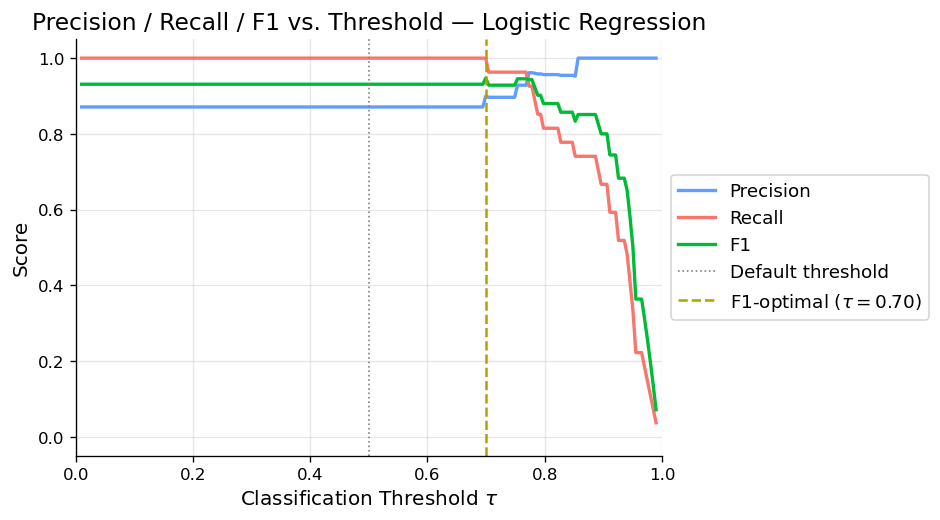

In [ ]:
best_probas = clf_probas[best_clf_name]
thresholds = np.linspace(0.01, 0.99, 200)

precisions = []
recalls = []
f1s = []

for tau in thresholds:
    y_pred_tau = (best_probas >= tau).astype(int)
    precisions.append(precision_score(y_clf_test, y_pred_tau, zero_division=0))
    recalls.append(recall_score(y_clf_test, y_pred_tau, zero_division=0))
    f1s.append(f1_score(y_clf_test, y_pred_tau, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, precisions, color=PERIWINKLE, lw=2, label="Precision")
ax.plot(thresholds, recalls, color=SALMON, lw=2, label="Recall")
ax.plot(thresholds, f1s, color=EMERALD, lw=2, label="F1")
ax.axvline(0.5, color="grey", ls=":", lw=1, label="Default threshold")

# Mark the F1-optimal threshold
best_tau_idx = np.argmax(f1s)
best_tau = thresholds[best_tau_idx]
ax.axvline(
    best_tau,
    color=GOLD,
    ls="--",
    lw=1.5,
    label=f"F1-optimal ($\\tau = {best_tau:.2f}$)",
)

ax.set_xlabel("Classification Threshold $\\tau$")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F1 vs. Threshold — {best_clf_name}")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### 7.3 Effect of Threshold on the Confusion Matrix

To make the trade-off concrete, we show the confusion matrix at three thresholds:
$\tau = 0.3$ (aggressive, high recall), $\tau = 0.5$ (default), and $\tau = 0.7$
(conservative, high precision).

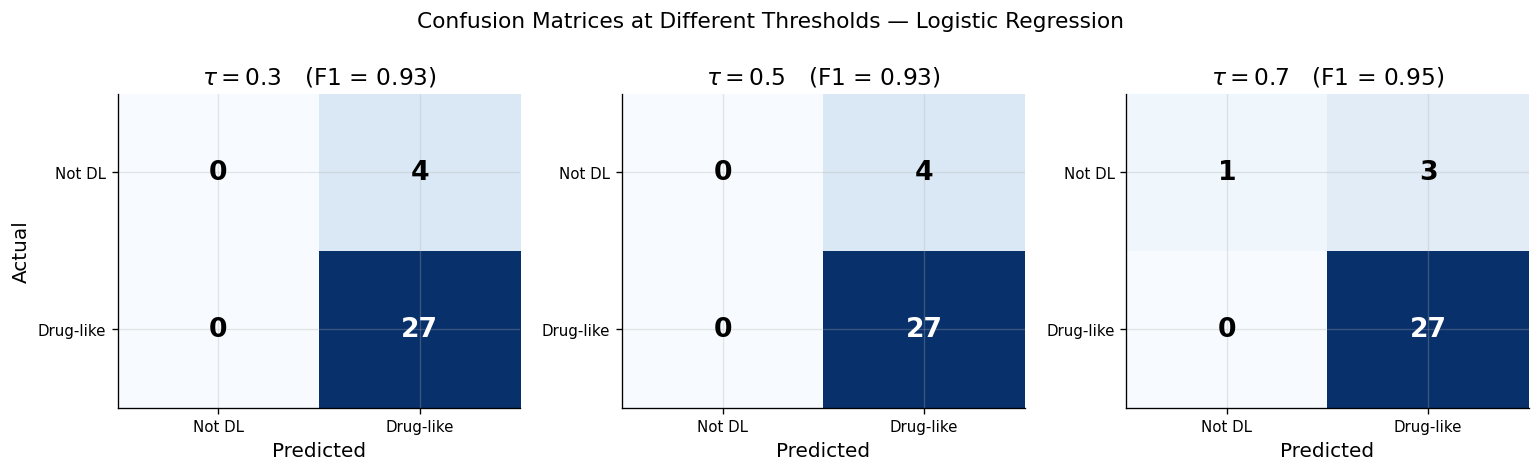

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
threshold_vals = [0.3, 0.5, 0.7]
label_names = ["Not DL", "Drug-like"]

for ax, tau in zip(axes, threshold_vals):
    y_pred_tau = (best_probas >= tau).astype(int)
    cm_tau = confusion_matrix(y_clf_test, y_pred_tau)
    im = ax.imshow(cm_tau, cmap="Blues", aspect="auto")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(label_names, fontsize=9)
    ax.set_yticklabels(label_names, fontsize=9)
    ax.set_xlabel("Predicted")
    if tau == 0.3:
        ax.set_ylabel("Actual")
    f1_tau = f1_score(y_clf_test, y_pred_tau, zero_division=0)
    ax.set_title(f"$\\tau = {tau}$   (F1 = {f1_tau:.2f})")
    for i in range(2):
        for j in range(2):
            color = "white" if cm_tau[i, j] > cm_tau.max() / 2 else "black"
            ax.text(
                j,
                i,
                str(cm_tau[i, j]),
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=color,
            )

plt.suptitle(
    f"Confusion Matrices at Different Thresholds — {best_clf_name}", fontsize=13
)
plt.tight_layout()
plt.show()

**Observation.** Lowering $\tau$ from 0.5 to 0.3 reduces false negatives (we catch more
drug-like molecules) but increases false positives. Raising $\tau$ to 0.7 has the opposite
effect. The right choice depends on the application context.

---

## 8. Putting It All Together

### 8.1 End-to-End Prediction on New Molecules

The real test of any ML pipeline is deployment on **unseen data**. Below we take five
well-known molecules that were *not* in our training set and push them through the full
pipeline:

$$
\text{SMILES} \xrightarrow{\text{RDKit}} \mathbf{x}
\xrightarrow{\text{StandardScaler}} \tilde{\mathbf{x}}
\xrightarrow{\text{Model}} \hat{y}
$$

We predict both LogP (regression) and drug-likeness (classification).

In [ ]:
new_molecules = [
    ("Melatonin", "COc1ccc2[nH]cc(CCNC(C)=O)c2c1"),
    ("Caffeine", "Cn1c(=O)c2c(ncn2C)n(C)c1=O"),
    ("Acetaminophen", "CC(=O)Nc1ccc(O)cc1"),
    ("Aspirin", "CC(=O)Oc1ccccc1C(=O)O"),
    ("Penicillin G", "O=C(O)C1N2C(=O)C(NC(=O)Cc3ccccc3)C2SC1(C)C"),
]

# Check which of these are already in training data
train_smiles = set(df["SMILES"].values)
for name, smi in new_molecules:
    status = "IN training set" if smi in train_smiles else "NOT in training set"
    print(f"  {name:16s} — {status}")

# Compute descriptors
new_rows = []
for name, smi in new_molecules:
    desc = compute_descriptors(smi)
    desc["Name"] = name
    new_rows.append(desc)

df_new = pd.DataFrame(new_rows)

# Regression prediction (LogP)
X_new_reg = df_new[feature_cols].values
df_new["Predicted_LogP"] = gb_pipe.predict(X_new_reg)
df_new["True_LogP"] = df_new["LogP"]

# Classification prediction (drug-likeness)
X_new_clf = df_new[clf_feature_cols].values
best_clf_pipe = clf_models[best_clf_name]
df_new["DrugLike_Prob"] = best_clf_pipe.predict_proba(X_new_clf)[:, 1]
df_new["DrugLike_Pred"] = best_clf_pipe.predict(X_new_clf)

# Actual drug-likeness (from Lipinski rules)
df_new["DrugLike_Actual"] = (
    (df_new["MolWt"] <= 500)
    & (df_new["LogP"] <= 5)
    & (df_new["HBD"] <= 5)
    & (df_new["HBA"] <= 10)
).astype(int)

display_cols = [
    "Name",
    "MolWt",
    "True_LogP",
    "Predicted_LogP",
    "DrugLike_Actual",
    "DrugLike_Prob",
    "DrugLike_Pred",
]
df_new[display_cols].round(2)

  Melatonin        — IN training set
  Caffeine         — IN training set
  Acetaminophen    — IN training set
  Aspirin          — IN training set
  Penicillin G     — IN training set


,Name,MolWt,True_LogP,Predicted_LogP,DrugLike_Actual,DrugLike_Prob,DrugLike_Pred
0,Melatonin,232.28,1.86,1.87,1,0.97,1
1,Caffeine,194.19,-1.03,-1.02,1,0.98,1
2,Acetaminophen,151.16,1.35,1.35,1,0.99,1
3,Aspirin,180.16,1.31,1.31,1,0.98,1
4,Penicillin G,334.40,0.86,0.84,1,0.93,1


### 8.2 How Confident Should We Be?

These predictions come with important caveats:

1. **Applicability domain.** Our model was trained on ~130 drug molecules. Predictions on
   molecules that are chemically very different from the training set (e.g., large
   macrocycles, peptides, inorganic compounds) are unreliable. In practice, one should
   check whether a new molecule falls within the training set's feature-space convex hull
   or within some distance threshold.

2. **Feature limitations.** Our nine descriptors capture global molecular properties but
   miss important structural details — pharmacophore patterns, 3-D shape, stereochemistry.
   Molecular fingerprints (as introduced in Notebook 03 of this module) provide much richer representations.

3. **Target quality.** Our LogP "ground truth" is itself a *computed* value (Crippen
   fragments), not an experimental measurement. Real QSAR studies use experimentally
   measured properties.

4. **Dataset size.** With ~130 molecules, we are in a low-data regime. The variance of our
   performance estimates is high, as the cross-validation boxplots showed.

---

## Key Takeaways

- **The molecular-ML pipeline** transforms SMILES strings into numeric descriptors, then
  applies standard supervised-learning algorithms. The chemistry enters through
  featurisation; the modelling is pure statistics.

- **Feature engineering matters.** The choice of molecular descriptors directly determines
  what information is available to the model. Domain knowledge (chemistry, pharmacology)
  guides this choice.

- **Tree-based ensembles** (Random Forest, Gradient Boosting) often outperform linear
  models on molecular data because descriptor-property relationships are typically
  nonlinear and involve interactions.

- **Cross-validation** gives more reliable performance estimates than a single train/test
  split, especially with small datasets.

- **Feature importance** connects the model back to chemistry. TPSA, HBD, and molecular
  size emerge as key drivers of LogP — consistent with physical chemistry.

- **Threshold tuning** allows you to trade off precision and recall based on the
  application's cost structure. In drug discovery, the optimal threshold is rarely 0.5.

- **Applicability domain** must always be considered: a model is only as reliable as the
  chemical space it was trained on.

In [27]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
